# Episode 1: Simple Neural Classifier

**Goal**: Classify text documents into categories (Cinema, Music, Science)

---

## The Pipeline

```
Text ==> Tokenization ==> Bag-of-Words ==> Neural Network ==> Prediction
```

### What We'll Build:
1. **Tokenization**: Split text into words
2. **Bag-of-Words**: Binary representation (word present/absent)
3. **Neural Network**: 2-layer feedforward network
4. **Training**: Learn to distinguish categories
5. **Prediction**: Classify new documents

---

## Why This Matters

This is the foundation of:
- Spam filters
- Sentiment analysis
- Topic classification
- Any text categorization task

**Key Insight**: Neural networks can learn patterns in text data automatically!

In [1]:
import re
import torch
import torch.nn as nn

# Set random seed for reproducibility
torch.manual_seed(42)

---

## Part 1: The Dataset

We'll use a tiny toy dataset with 10 documents across 3 categories:
- **Cinema** (label 1): Movies, films
- **Music** (label 2): Rock, folk, listening
- **Science** (label 3): Research, math, discovery

In [2]:
docs = [
    "Movies are fun for everyone.",
    "Watching movies is great fun.",
    "Enjoy a great movie today.",
    "Research is interesting and important.",
    "Learning math is very important.",
    "Science discovery is interesting.",
    "Rock is great to listen to.",
    "Listen to music for fun.",
    "Music is fun for everyone.",
    "Listen to folk music!"
]

labels = [1, 1, 1, 3, 3, 3, 2, 2, 2, 2]  # 1=Cinema, 2=Music, 3=Science
num_classes = len(set(labels))

print(f"Number of documents: {len(docs)}")
print(f"Number of classes: {num_classes}")
print("\n# Example documents\n\nFormat: [{label}] {text}\n")
for i in range(3):
    print(f"  [{labels[i]}] {docs[i]}")

Number of documents: 10
Number of classes: 3

# Example documents

Format: [{label}] {text}

  [1] Movies are fun for everyone.
  [1] Watching movies is great fun.
  [1] Enjoy a great movie today.


---

## Part 2: Text Preprocessing

### Step 1: Tokenization

Split text into individual words (tokens) and convert to lowercase.

In [3]:
def tokenize(text):
    """Convert text to lowercase and extract words using our beloved regex"""
    return re.findall(r"\w+", text.lower())

# Test tokenization
example_text = "Movies are fun for everyone."
tokens = tokenize(example_text)
print(f"Original: {example_text}")
print(f"Tokens: {tokens}")

Original: Movies are fun for everyone.
Tokens: ['movies', 'are', 'fun', 'for', 'everyone']


### Step 2: Build Vocabulary

Create a dictionary mapping each unique word to an index.

In [16]:
def get_vocabulary(texts):
    """Build vocabulary from all documents"""
    tokens = {token for text in texts for token in tokenize(text)}
    return {word: idx for idx, word in enumerate(sorted(tokens))}

vocabulary = get_vocabulary(docs)

print(f"Vocabulary size: {len(vocabulary)}")
print("\nAll words in vocabulary:")
for word, idx in list(vocabulary.items()):
    print(f"  '{word}': {idx}")

Vocabulary size: 26

All words in vocabulary:
  'a': 0
  'and': 1
  'are': 2
  'discovery': 3
  'enjoy': 4
  'everyone': 5
  'folk': 6
  'for': 7
  'fun': 8
  'great': 9
  'important': 10
  'interesting': 11
  'is': 12
  'learning': 13
  'listen': 14
  'math': 15
  'movie': 16
  'movies': 17
  'music': 18
  'research': 19
  'rock': 20
  'science': 21
  'to': 22
  'today': 23
  'very': 24
  'watching': 25


---

## Part 3: Bag-of-Words (BoW) Representation

### What is Bag-of-Words?

A **binary vector** where each position corresponds to a word in the vocabulary:
- `1` = word is present in the document
- `0` = word is absent

**Example**:
- Vocabulary: `["and", "are", "discovery", ..., "fun", ..., "movies", ...]`
- Document: "Movies are fun"
- BoW vector: `[0, 1, 0, ..., 1, ..., 1, ...]`

### Limitations:
- (-) Loses word order ("dog bites man" = "man bites dog")
- (-) Ignores word frequency
- (-)  Very high dimensionality (vocab_size)
- (+)  But: Simple and works for basic classification!

In [5]:
def doc_to_bow(doc, vocabulary):
    """Convert document to binary bag-of-words vector"""
    tokens = set(tokenize(doc))  # Use set to get unique tokens
    bow = [0] * len(vocabulary)
    for token in tokens:
        if token in vocabulary:
            bow[vocabulary[token]] = 1
    return bow

# Test on 2 document
for example_doc in [docs[0], docs[3]]:
    bow_vector = doc_to_bow(example_doc, vocabulary)
    print(f"Document: {example_doc}")
    print(f"BoW vector length: {len(bow_vector)}")
    print(f"Number of 1s (words present): {sum(bow_vector)}")
    print(f"BoW vector: {bow_vector}\n")

Document: Movies are fun for everyone.
BoW vector length: 26
Number of 1s (words present): 5
BoW vector: [0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

Document: Research is interesting and important.
BoW vector length: 26
Number of 1s (words present): 5
BoW vector: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]



### Convert All Documents to BoW Vectors

In [6]:
# Convert all documents to BoW vectors
vectors = torch.tensor(
    [doc_to_bow(doc, vocabulary) for doc in docs], 
    dtype=torch.float32
)

# Convert labels to tensor (subtract 1 to make them 0-indexed)
labels_tensor = torch.tensor(labels, dtype=torch.long) - 1

print(f"Input vectors shape: {vectors.shape}")  # [10 documents, vocab_size features]
print(f"Labels shape: {labels_tensor.shape}")  # [10 documents]
print(f"Labels (0-indexed): {labels_tensor}")

Input vectors shape: torch.Size([10, 26])
Labels shape: torch.Size([10])
Labels (0-indexed): tensor([0, 0, 0, 2, 2, 2, 1, 1, 1, 1])


---

## Part 4: Build the Neural Network

### Architecture:

```
Input Layer (vocab_size dimensions)
         ↓
Hidden Layer (50 neurons) + ReLU activation
         ↓
Output Layer (3 neurons, one per class)
```

### How It Works:
1. **Input**: Binary BoW vector (e.g., 28 dimensions for our vocabulary)
2. **Hidden Layer**: Transforms input into 50-dimensional representation
3. **ReLU**: Non-linear activation (keeps positive values, zeros negative)
4. **Output**: 3 scores (logits), one per class
5. **Softmax** (handled by loss function): Converts logits to probabilities

In [7]:
input_dim = len(vocabulary) 
hidden_dim = 50 
output_dim = num_classes

print(f"Input dimension: {input_dim}")
print(f"Hidden dimension: {hidden_dim}")
print(f"Output dimension: {output_dim}")

Input dimension: 26
Hidden dimension: 50
Output dimension: 3


In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # First layer
        self.relu = nn.ReLU()                        # Activation function
        self.fc2 = nn.Linear(hidden_dim, output_dim) # Output layer
    
    def forward(self, bow_vector):
        """Forward pass through the network"""
        hidden = self.fc1(bow_vector)      # Linear transformation
        hidden_activated = self.relu(hidden)     # Non-linear activation
        output_logits = self.fc2(hidden_activated)      # Output logits
        return output_logits

model = SimpleClassifier(input_dim, hidden_dim, output_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

SimpleClassifier(
  (fc1): Linear(in_features=26, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=3, bias=True)
)

Total parameters: 1503


```mermaid
flowchart TB
    subgraph Input
        A["Document: 'Movies are fun'<br/>↓<br/>Bag-of-Words Vector<br/>[1, 0, 1, 0, ...]<br/>Length: 28"]
    end
    
    subgraph Network["Neural Network"]
        B["fc1: Linear(28, 50)<br/>Weight: [28×50]<br/>Bias: [50]"]
        C["ReLU()"]
        D["fc2: Linear(50, 3)<br/>Weight: [50×3]<br/>Bias: [3]"]
    end
    
    subgraph Output
        E["Logits: [2.3, -0.5, 1.1]<br/>↓<br/>Softmax<br/>↓<br/>Probabilities: [0.7, 0.1, 0.2]<br/>↓<br/>Prediction: Cinema"]
    end
    
    A --> B --> C --> D --> E
    
    style A fill:#bbdefb
    style E fill:#c8e6c9
    style B fill:#fff9c4
    style D fill:#fff9c4
```

---

## Part 5: Training the Network

### Training Loop:
1. **Forward pass**: Compute predictions
2. **Compute loss**: How wrong are we? (Cross-Entropy Loss)
3. **Backward pass**: Compute gradients (automatic!)
4. **Update weights**: Use SGD optimizer to improve
5. **Repeat** 3,000 times

### Loss Function:
**CrossEntropyLoss** = Softmax + Negative Log-Likelihood
- Converts raw scores (logits) to probabilities
- Penalizes wrong predictions
- Lower loss = better predictions

In [9]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Combines softmax + cross-entropy
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Training configuration:")
print(f"  Loss: CrossEntropyLoss")
print(f"  Optimizer: SGD")
print(f"  Learning rate: 0.01")
print(f"  Iterations: 3000")

Training configuration:
  Loss: CrossEntropyLoss
  Optimizer: SGD
  Learning rate: 0.01
  Iterations: 3000


In [10]:
# Training loop
num_epochs = 3000
losses = []

for step in range(num_epochs):
    # Forward pass
    optimizer.zero_grad()  # Reset gradients
    outputs = model(vectors)  # Get predictions
    loss = criterion(outputs, labels_tensor)  # Compute loss
    
    # Backward pass
    loss.backward()  # Compute gradients
    optimizer.step()  # Update weights
    
    # Track loss
    losses.append(loss.item())
    
    # Print progress
    if (step + 1) % 500 == 0:
        print(f"Epoch [{step+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("\n✅ Training complete!")

Epoch [500/3000], Loss: 0.2278
Epoch [1000/3000], Loss: 0.0546
Epoch [1500/3000], Loss: 0.0256
Epoch [2000/3000], Loss: 0.0157
Epoch [2500/3000], Loss: 0.0110
Epoch [3000/3000], Loss: 0.0084

✅ Training complete!


### Visualize Training Loss

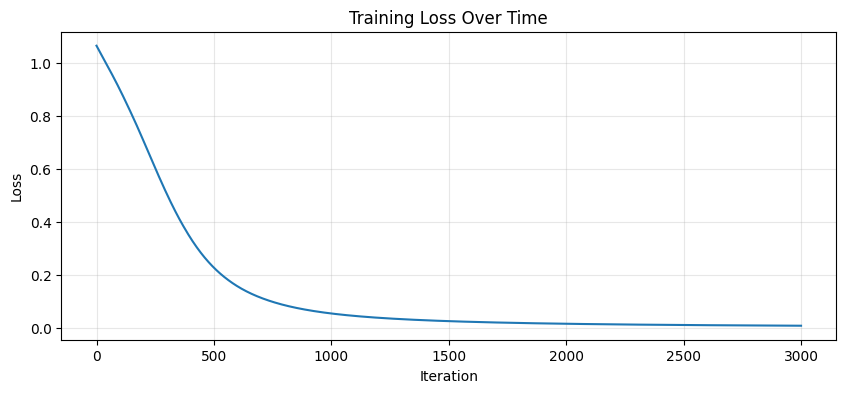

Initial loss: 1.0642
Final loss: 0.0084
Loss reduction: 99.2%


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {((losses[0] - losses[-1]) / losses[0] * 100):.1f}%")

---

## Part 6: Evaluate on Training Data

Let's see how well the model learned the training data.

In [12]:
# Evaluate on training data
class_names = ["Cinema", "Music", "Science"]

model.eval()  # Set to evaluation mode
with torch.no_grad():
    outputs = model(vectors)
    _, predicted = torch.max(outputs, 1)
    
    print("Training Set Performance:")
    print("="*60)
    correct = 0
    for i, doc in enumerate(docs):
        true_label = labels_tensor[i].item()
        pred_label = predicted[i].item()
        correct += (true_label == pred_label)
        
        status = "✓" if true_label == pred_label else "✗"
        print(f"{status} {doc}")
        print(f"  True: {class_names[true_label]}, Predicted: {class_names[pred_label]}")
    
    accuracy = 100 * correct / len(docs)
    print(f"\nAccuracy: {accuracy:.1f}% ({correct}/{len(docs)})")

Training Set Performance:
✓ Movies are fun for everyone.
  True: Cinema, Predicted: Cinema
✓ Watching movies is great fun.
  True: Cinema, Predicted: Cinema
✓ Enjoy a great movie today.
  True: Cinema, Predicted: Cinema
✓ Research is interesting and important.
  True: Science, Predicted: Science
✓ Learning math is very important.
  True: Science, Predicted: Science
✓ Science discovery is interesting.
  True: Science, Predicted: Science
✓ Rock is great to listen to.
  True: Music, Predicted: Music
✓ Listen to music for fun.
  True: Music, Predicted: Music
✓ Music is fun for everyone.
  True: Music, Predicted: Music
✓ Listen to folk music!
  True: Music, Predicted: Music

Accuracy: 100.0% (10/10)


---

## Part 7: Test on New Documents

The real test: Can the model classify documents it has never seen before?

In [13]:
# New test documents
new_docs = [
    "Listening to rock music is fun.",
    "I love science very much.",
    "Films are my passion"
]

# Convert to BoW vectors
new_doc_vectors = torch.tensor(
    [doc_to_bow(new_doc, vocabulary) for new_doc in new_docs],
    dtype=torch.float32
)

print(f"Test set size: {len(new_docs)} documents")
print(f"Input shape: {new_doc_vectors.shape}")

Test set size: 3 documents
Input shape: torch.Size([3, 26])


In [14]:
# Make predictions
with torch.no_grad():
    outputs = model(new_doc_vectors)
    probabilities = torch.softmax(outputs, dim=1)  # Convert to probabilities
    predicted_ids = torch.argmax(outputs, dim=1)
    
    print("\nTest Document Predictions:")
    print("="*60)
    
    for i, new_doc in enumerate(new_docs):
        pred_class = class_names[predicted_ids[i].item()]
        probs = probabilities[i]
        
        print(f"\nDocument: \"{new_doc}\"")
        print(f"Prediction: {pred_class}")
        print(f"Confidence:")
        for j, class_name in enumerate(class_names):
            print(f"  {class_name}: {probs[j].item():.2%}")


Test Document Predictions:

Document: "Listening to rock music is fun."
Prediction: Music
Confidence:
  Cinema: 0.18%
  Music: 99.53%
  Science: 0.29%

Document: "I love science very much."
Prediction: Science
Confidence:
  Cinema: 20.40%
  Music: 9.26%
  Science: 70.34%

Document: "Films are my passion"
Prediction: Cinema
Confidence:
  Cinema: 59.37%
  Music: 15.76%
  Science: 24.88%


In [15]:
print(model)

SimpleClassifier(
  (fc1): Linear(in_features=26, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=3, bias=True)
)


```mermaid
graph TD
    A[Input: Bag-of-Words<br/>Shape: vocab_size=28] --> B[Linear Layer fc1<br/>28 → 50 neurons<br/>Parameters: 1,450]
    B --> C[ReLU Activation<br/>max 0, x]
    C --> D[Linear Layer fc2<br/>50 → 3 neurons<br/>Parameters: 153]
    D --> E[Output: Logits<br/>3 class scores]
    E --> F[CrossEntropyLoss<br/>applies Softmax internally]
    F --> G[Predictions<br/>Cinema, Music, Science]
    
    style A fill:#e1f5ff
    style E fill:#ffe1e1
    style G fill:#e1ffe1
    style C fill:#fff4e1
```

---

## 📝 Episode 1 Summary

### What We Built:

✓ **Text preprocessing**: Tokenization → Vocabulary → Bag-of-Words  
✓ **Neural network**: 2-layer feedforward classifier  
✓ **Training**: SGD optimization with cross-entropy loss  
✓ **Prediction**: Classify new, unseen documents  

### Key Insights:

1. **Neural networks learn representations**: The hidden layer learns features that distinguish categories
2. **Bag-of-Words is simple but limited**: Loses word order and context
3. **Training = optimization**: Iteratively improve weights to minimize loss

### Limitations of This Approach:

❌ **Binary BoW**: Loses word order ("dog bites man" = "man bites dog")  
❌ **High dimensionality**: Vocabulary size can be huge (10k-100k words)  
❌ **No semantic understanding**: "happy" and "joyful" are treated as completely different  

---

## 🔜 What's Next: Episode 2 - Embeddings

**Problem**: Binary vectors are sparse and don't capture meaning.

**Solution**: Learn **dense embeddings** where:
- Similar words have similar vectors
- Much lower dimensionality (50-300 vs. 10,000+)
- Captures semantic relationships

This is the foundation for all modern NLP!